In [2]:
                            #### GBM SIZE IN VITRO SAMPLE SIZE CALCULATION ####
                                  

In [3]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
pd.DataFrame.iteritems = pd.DataFrame.items

from random import gauss as rgauss
import numpy as np
from scipy.stats.mstats import gmean
from tqdm.notebook import tqdm
import pingouin as pg

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

/Users/roberto/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
def mgauss(mu=1, sigma=.1, threshold=2):
    """This limits the generated values within ± <threshold> standard deviations
    """
    
    val = mu + sigma * threshold * 2

    while abs(val - mu) > sigma * threshold: 
        val = rgauss(mu, sigma)

    return val

In [5]:
# GBM size at day 7 mean values and standard deviation have been calculated based on previous literature (10.1073/pnas.2118697119 and 10.1002/smll.202302280)

In [6]:
# params
# ======

gbm_std = 0.12       # standard deviation of GBM size

gbm_high = 1         # mean GBM size untreated (e.g. SEMA6Ahigh)
gbm_high_tmz = 0.73  # mean GBM size TMZ-treated (e.g. SEMA6Ahigh_tmz)
gbm_low = 0.8        # estimated GBM size of SEMA6Alow (20% reduction vs SEMA6Ahigh)

<Axes: >

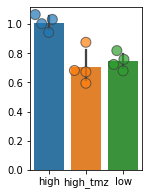

In [7]:
#plot an example

n = 4         # sample size per experimental group

high      = [mgauss(mu=gbm_high,     sigma=gbm_std * gbm_high,     threshold=3) for _ in range(n)]
high_tmz  = [mgauss(mu=gbm_high_tmz, sigma=gbm_std * gbm_high_tmz, threshold=3) for _ in range(n)]
low       = [mgauss(mu=gbm_low,      sigma=gbm_std * gbm_low,      threshold=3) for _ in range(n)]

repack = {"high": high, "high_tmz": high_tmz, "low": low}
repack = pd.DataFrame(repack, index=range(n))

plt.figure(figsize=(2,3))
sns.barplot(data=repack)
sns.swarmplot(data=repack, s=10, linewidth=1, alpha=.7)

In [11]:
#compute p-values for ttest and Tukey's post-hoc test over 1000 simulations for different sample sizes

n_values = [3, 4, 5, 6, 7, 8, 9, 10]

t_power = []
a1_power = []
a2_power = []

for n in n_values:
    t_pvals = []
    a1_pvals = []
    a2_pvals = []

    n_sims = 1000
    for i in tqdm(range(n_sims)):
        high      = [mgauss(mu=gbm_high,     sigma=gbm_std * gbm_high,     threshold=3) for _ in range(n)]
        high_tmz  = [mgauss(mu=gbm_high_tmz, sigma=gbm_std * gbm_high_tmz, threshold=3) for _ in range(n)]
        low       = [mgauss(mu=gbm_low,      sigma=gbm_std * gbm_low,      threshold=3) for _ in range(n)]
    
        t_res = pg.ttest(high, low)
        t_pval = t_res["p-val"].iloc[0]
        t_pvals.append(t_pval)

        repacked_vals = high + high_tmz + low
        repacked_hues = ["high" for _ in range(n)] + ["high_tmz" for _ in range(n)] + ["low" for _ in range(n)]
        repack = {"vals": repacked_vals, "tags": repacked_hues}
        repack = pd.DataFrame(repack, index=range(n * 3))
        #a_res = pg.anova(data=repack, dv='vals', between='tags', detailed=False)
        posthoc = pg.pairwise_tests(data=repack, dv='vals', between='tags', parametric=True, padjust='fdr_bh', effsize='hedges')
        a1_pval = posthoc[(posthoc["A"] == "high") &  (posthoc["B"] == "high_tmz")]["p-corr"].iloc[0]
        a1_pvals.append(a1_pval)
        a2_pval = posthoc[(posthoc["A"] == "high") &  (posthoc["B"] == "low")]["p-corr"].iloc[0]
        a2_pvals.append(a2_pval)
        
    t = np.array(t_pvals)
    a1 = np.array(a1_pvals)
    a2 = np.array(a2_pvals)  
    
    t_pow = sum(t < .05)
    a1_pow = sum(a1 < .05)
    a2_pow = sum(a2 < .05)
    
    t_power.append(t_pow)
    a1_power.append(a1_pow)
    a2_power.append(a2_pow)
    
    print(f"For n = {n} the power of ttest is {sum(t < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between high and high_tmz is {sum(a1 < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between high and low is {sum(a2 < .05)/10}%")

  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 3 the power of ttest is 40.1%
For n = 3 the power of Tukey's post-hoc test between high and high_tmz is 44.9%
For n = 3 the power of Tukey's post-hoc test between high and low is 30.3%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 4 the power of ttest is 57.4%
For n = 4 the power of Tukey's post-hoc test between high and high_tmz is 71.5%
For n = 4 the power of Tukey's post-hoc test between high and low is 47.0%


  0%|          | 0/1000 [00:00<?, ?it/s]

...

For n = 8 the power of ttest is 94.6%
For n = 8 the power of Tukey's post-hoc test between high and high_tmz is 99.1%
For n = 8 the power of Tukey's post-hoc test between high and low is 91.6%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 9 the power of ttest is 95.4%
For n = 9 the power of Tukey's post-hoc test between high and high_tmz is 99.8%
For n = 9 the power of Tukey's post-hoc test between high and low is 95.1%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 10 the power of ttest is 97.4%
For n = 10 the power of Tukey's post-hoc test between high and high_tmz is 99.7%
For n = 10 the power of Tukey's post-hoc test between high and low is 96.7%


In [12]:
posthoc

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,tags,high,high_tmz,False,True,4.455696,18.0,two-sided,0.000305,0.000792,fdr_bh,78.134,1.908452
1,tags,high,low,False,True,4.208521,18.0,two-sided,0.000528,0.000792,fdr_bh,50.037,1.802582
2,tags,high_tmz,low,False,True,-0.420148,18.0,two-sided,0.679350,0.679350,fdr_bh,0.423,-0.179956


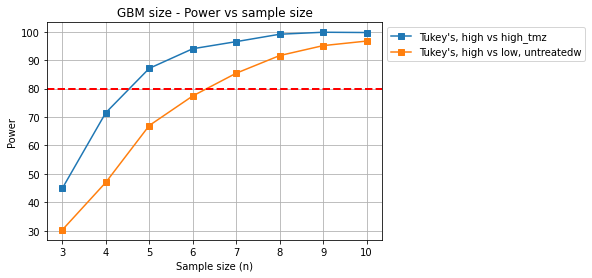

In [14]:
plt.figure()

#plt.plot(n_values, np.array(t_power), marker='o', label='t-test')
plt.plot(n_values, np.array(a1_power)/10, marker='s', label="Tukey's, high vs high_tmz")
plt.plot(n_values, np.array(a2_power)/10, marker='s', label="Tukey's, high vs low, untreatedw")

plt.xlabel('Sample size (n)')
plt.ylabel('Power')
plt.title('GBM size - Power vs sample size')

threshold = 80
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)

plt.show()